<a href="https://colab.research.google.com/github/Tolureis/CMPE-460-Deep-Learning/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your loss = 12.367, Correct loss = 12.367
Your gradients: (-21.904,-26.840)
Approx gradients: (-21.903,-26.839)


/tmp/ipython-input-2006891356.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Your gradients: (%3.3f,%3.3f)" % (gradient[0], gradient[1]))


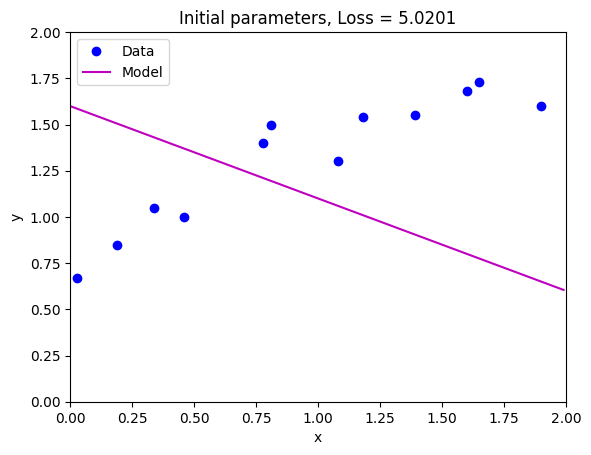

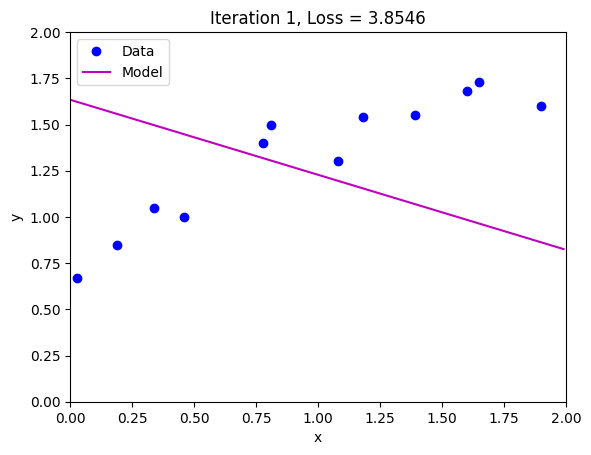

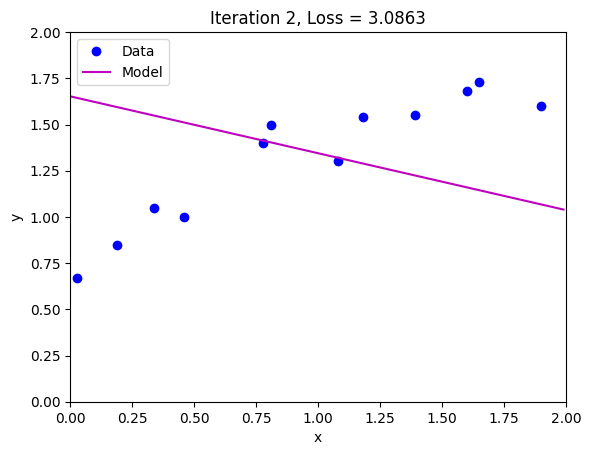

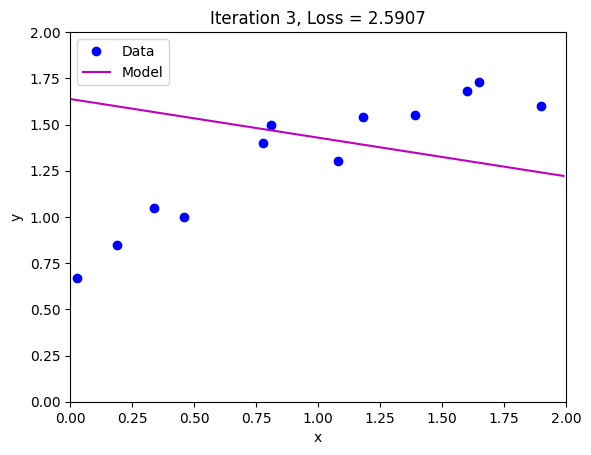

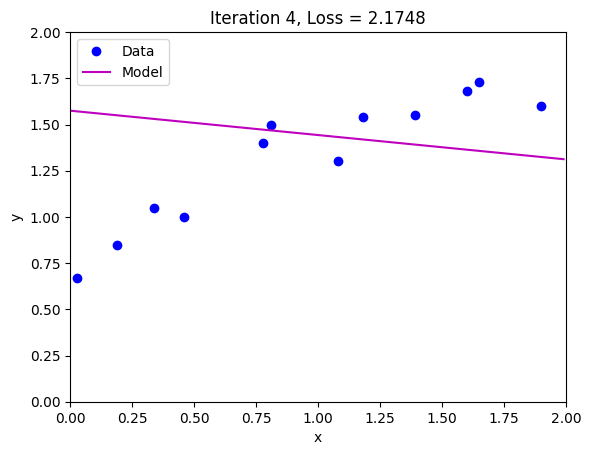

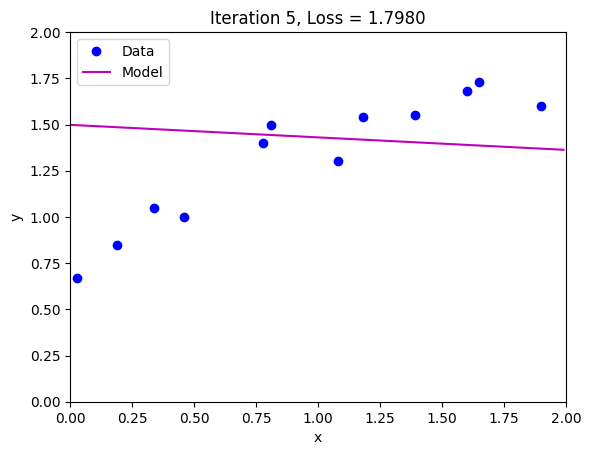

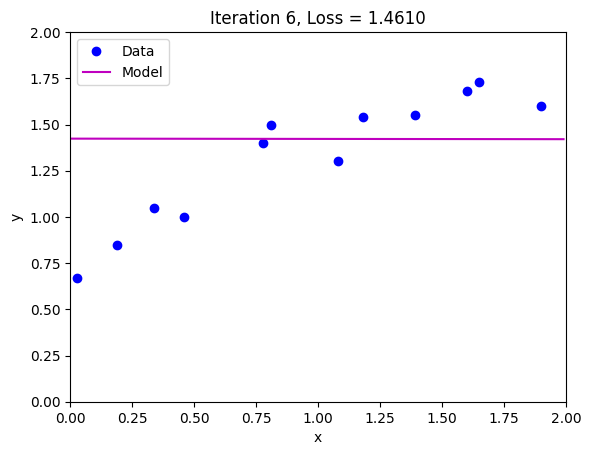

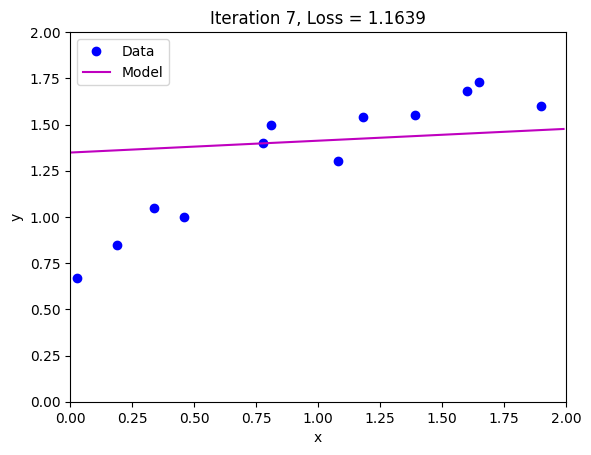

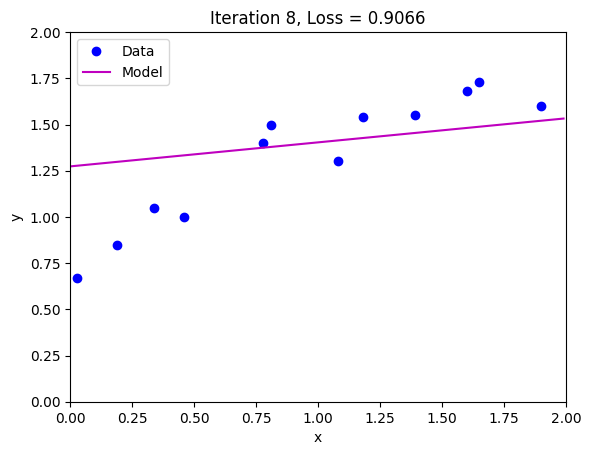

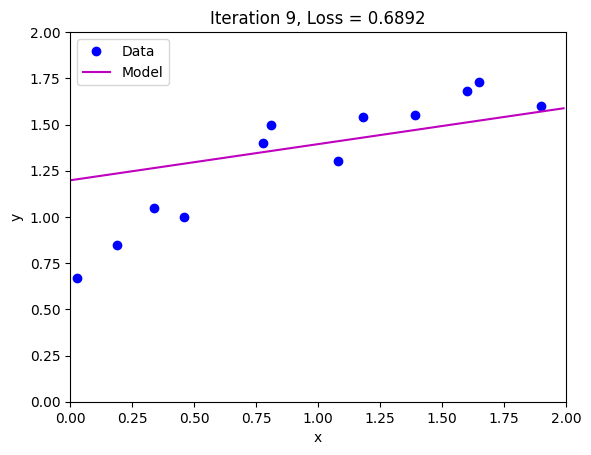

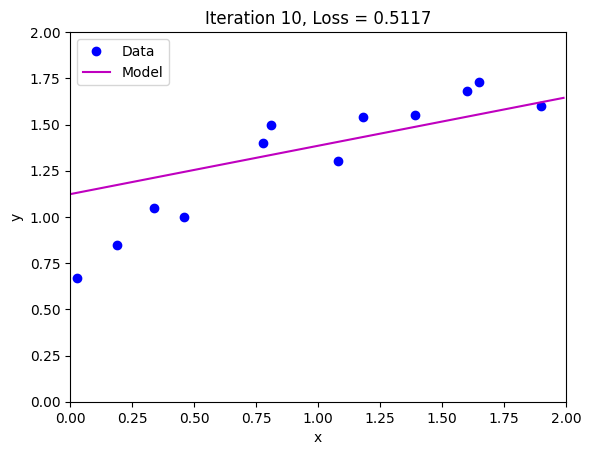

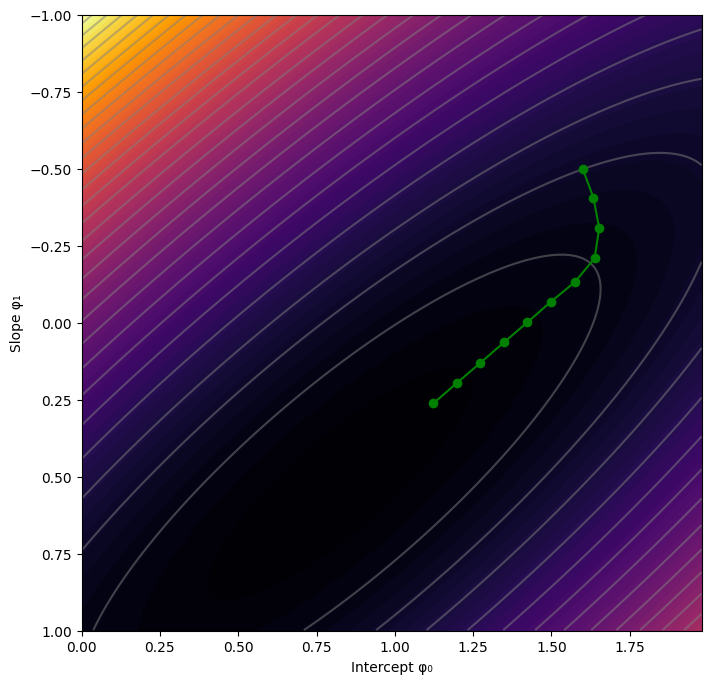

In [ ]:
# -*- coding: utf-8 -*-
# Complete Gradient Descent Implementation (6_2_Gradient_Descent.py)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# =====================
# DATA AND MODEL SETUP
# =====================

data = np.array([[0.03,0.19,0.34,0.46,0.78,0.81,1.08,1.18,1.39,1.60,1.65,1.90],
                 [0.67,0.85,1.05,1.00,1.40,1.50,1.30,1.54,1.55,1.68,1.73,1.60]])

def model(phi, x):
    """Linear model y = phi0 + phi1 * x"""
    return phi[0] + phi[1] * x

def draw_model(data, model, phi, title=None):
    x_model = np.arange(0, 2, 0.01)
    y_model = model(phi, x_model)

    fig, ax = plt.subplots()
    ax.plot(data[0, :], data[1, :], 'bo', label="Data")
    ax.plot(x_model, y_model, 'm-', label="Model")
    ax.set_xlim([0, 2]); ax.set_ylim([0, 2])
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend()
    if title: ax.set_title(title)
    plt.show()

# =====================
# 1. LOSS FUNCTION
# =====================

def compute_loss(data_x, data_y, model, phi):
    """Sum of squared errors"""
    pred_y = model(phi, data_x)
    loss = np.sum((data_y - pred_y)**2)
    return loss

# test
loss = compute_loss(data[0, :], data[1, :], model, np.array([[0.6], [-0.2]]))
print('Your loss = %3.3f, Correct loss = %3.3f' % (loss, 12.367))

# =====================
# 2. GRADIENT FUNCTION
# =====================

def compute_gradient(data_x, data_y, phi):
    """Compute gradient of the loss wrt phi0 and phi1"""
    y_pred = model(phi, data_x)
    error = y_pred - data_y
    dl_dphi0 = 2 * np.sum(error)
    dl_dphi1 = 2 * np.sum(error * data_x)
    return np.array([[dl_dphi0], [dl_dphi1]])

# check gradient correctness
phi = np.array([[0.6], [-0.2]])
gradient = compute_gradient(data[0, :], data[1, :], phi)
print("Your gradients: (%3.3f,%3.3f)" % (gradient[0], gradient[1]))

delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Approx gradients: (%3.3f,%3.3f)" % (dl_dphi0_est, dl_dphi1_est))

# =====================
# 3. LINE SEARCH (given)
# =====================

def loss_function_1D(dist_prop, data, model, phi_start, search_direction):
    return compute_loss(data[0,:], data[1,:], model, phi_start + search_direction * dist_prop)

def line_search(data, model, phi, gradient, thresh=.00001, max_dist=0.1, max_iter=15, verbose=False):
    a, b, c, d = 0, 0.33*max_dist, 0.66*max_dist, 1.0*max_dist
    n_iter = 0

    while np.abs(b - c) > thresh and n_iter < max_iter:
        n_iter += 1
        lossa = loss_function_1D(a, data, model, phi, gradient)
        lossb = loss_function_1D(b, data, model, phi, gradient)
        lossc = loss_function_1D(c, data, model, phi, gradient)
        lossd = loss_function_1D(d, data, model, phi, gradient)

        if np.argmin((lossa, lossb, lossc, lossd)) == 0:
            b = a + (b - a) / 2
            c = a + (c - a) / 2
            d = a + (d - a) / 2
            continue
        if lossb < lossc:
            d = c
            b = a + (d - a) / 3
            c = a + 2*(d - a) / 3
            continue
        a = b
        b = a + (d - a) / 3
        c = a + 2*(d - a) / 3

    return (b + c) / 2.0

# =====================
# 4. GRADIENT DESCENT STEP
# =====================

def gradient_descent_step(phi, data, model):
    gradient = compute_gradient(data[0,:], data[1,:], phi)
    direction = -gradient / np.linalg.norm(gradient)  # normalize for stability
    alpha = line_search(data, model, phi, direction)
    phi_new = phi + alpha * direction
    return phi_new

# =====================
# 5. RUN OPTIMIZATION
# =====================

n_steps = 10
phi_all = np.zeros((2, n_steps+1))
phi_all[:, 0] = [1.6, -0.5]

loss = compute_loss(data[0, :], data[1, :], model, phi_all[:, 0:1])
draw_model(data, model, phi_all[:, 0:1], f"Initial parameters, Loss = {loss:.4f}")

for i in range(n_steps):
    phi_all[:, i+1:i+2] = gradient_descent_step(phi_all[:, i:i+1], data, model)
    loss = compute_loss(data[0,:], data[1,:], model, phi_all[:, i+1:i+2])
    draw_model(data, model, phi_all[:, i+1], f"Iteration {i+1}, Loss = {loss:.4f}")

# =====================
# 6. VISUALIZE TRAJECTORY
# =====================

def draw_loss_function(compute_loss, data, model, phi_iters=None):
    intercepts, slopes = np.meshgrid(np.arange(0.0, 2.0, 0.02), np.arange(-1.0, 1.0, 0.002))
    loss_mesh = np.zeros_like(slopes)
    for idslope, slope in np.ndenumerate(slopes):
        loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[intercepts[idslope]], [slope]]))

    fig, ax = plt.subplots(figsize=(8,8))
    cmap = plt.get_cmap('inferno')
    ax.contourf(intercepts, slopes, loss_mesh, 100, cmap=cmap)
    ax.contour(intercepts, slopes, loss_mesh, 30, colors='gray', alpha=0.5)
    if phi_iters is not None:
        ax.plot(phi_iters[0,:], phi_iters[1,:], 'go-')
    ax.set_ylim([1,-1])
    ax.set_xlabel('Intercept φ₀'); ax.set_ylabel('Slope φ₁')
    plt.show()

draw_loss_function(compute_loss, data, model, phi_all)
